# Visual Question Answering with A-OKVQA

**Deep Learning Midterm Project — 523H0173 & 523H0178**

| Component | Detail |
|-----------|--------|
| **Dataset** | A-OKVQA (Augmented OK-VQA) — COCO images + knowledge-requiring QA |
| **Data Expansion** | 3× rationale expansion (~17K → ~51K training samples) |
| **Image Encoder** | CNN from scratch / Pretrained ResNet-18 |
| **Question Encoder** | LSTM 2-layer, dropout=0.3, GloVe 300d |
| **Answer Decoder** | LSTM 2-layer, dropout=0.3, GloVe 300d (generative) |
| **Attention** | Bahdanau (Additive) with padding mask |
| **Loss** | CrossEntropy + Label Smoothing (0.1) |
| **Scheduler** | Cosine Annealing (20 epochs) + Early Stopping (patience=5) |
| **Decoding** | Greedy (train) / Beam Search width=5 + length penalty (eval) |
| **Metrics** | Accuracy, EM, F1, METEOR, BLEU-1/2/3/4 |
| **Config** | YAML-based configuration system |

**4 model variants compared:**
1. **M1** — CNN (scratch) + LSTM (baseline)
2. **M2** — CNN (scratch) + LSTM + Bahdanau Attention
3. **M3** — Pretrained ResNet-18 + LSTM
4. **M4** — Pretrained ResNet-18 + LSTM + Bahdanau Attention

**Key features & improvements:**
1. 3× data expansion using all 3 A-OKVQA rationales per question
2. LSTM 2-layer + Dropout 0.3 for both encoder and decoder
3. GloVe 300d pre-trained word embeddings
4. Label Smoothing (0.1) + Cosine Annealing LR
5. Attention padding mask (prevents attention leak to \<PAD\> tokens)
6. Beam Search with Wu et al. (2016) length normalization
7. Early stopping (patience=5) to prevent overfitting
8. 8 evaluation metrics: Accuracy, EM, F1, METEOR, BLEU-1/2/3/4
9. Modular code structure (`src/`) with YAML config (`configs/`)
10. Question-type breakdown analysis (yes/no, counting, what, who, etc.)
11. Attention overlay visualization on images
12. Confusion matrix & failure case analysis
13. CLI scripts for training, evaluation, and inference
14. Batch inference & ONNX export support
15. Multi-seed training for statistical significance

---
## 1. Setup & Imports

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# Standard imports
# ══════════════════════════════════════════════════════════════════════
import os
import sys
import random
import logging

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("wordnet", quiet=True)

# ══════════════════════════════════════════════════════════════════════
# Project modules (from src/)
# ══════════════════════════════════════════════════════════════════════
from src.config import Config
from src.data.preprocessing import (
    normalize_answer, majority_answer, extract_answer,
    expand_data_with_rationales, classify_question,
)
from src.data.dataset import Vocabulary, AOKVQA_Dataset, collate_fn, PAD_IDX, SOS_IDX, EOS_IDX, UNK_IDX
from src.data.glove import download_glove, load_glove_embeddings
from src.models.vqa_model import VQAModel
from src.models.encoder import CNNEncoder, QuestionEncoder
from src.models.decoder import AnswerDecoder
from src.models.attention import BahdanauAttention
from src.engine.trainer import train_model, EarlyStopping
from src.engine.evaluator import evaluate_model, evaluate_by_question_type, get_failure_cases
from src.utils.metrics import (
    compute_exact_match, compute_f1, compute_bleu,
    compute_meteor, compute_vqa_accuracy, batch_metrics,
)
from src.utils.helpers import get_device, decode_sequence, set_seed, setup_logging
from src.utils.visualization import (
    plot_training_curves, plot_radar_chart, plot_bar_chart,
    visualize_attention, visualize_attention_overlay,
    plot_confusion_matrix, plot_question_type_analysis,
)

# ══════════════════════════════════════════════════════════════════════
# Load config & setup
# ══════════════════════════════════════════════════════════════════════
cfg = Config.from_yaml("configs/default.yaml")

set_seed(cfg.seed)
logger = setup_logging(cfg.log_dir)

device = get_device() if cfg.device == "auto" else torch.device(cfg.device)
logger.info(f"Using device: {device}")
logger.info(f"Config loaded: seed={cfg.seed}, epochs={cfg.train.epochs}, lr={cfg.train.learning_rate}")
print(f"Config: configs/default.yaml")
print(f"Device: {device}")
print(f"Seed: {cfg.seed}")

In [ ]:
# All data processing utilities are now in src/data/
# - normalize_answer, majority_answer, extract_answer → src/data/preprocessing.py
# - expand_data_with_rationales → src/data/preprocessing.py
# - classify_question → src/data/preprocessing.py
# - Vocabulary, AOKVQA_Dataset, collate_fn → src/data/dataset.py
# - download_glove, load_glove_embeddings → src/data/glove.py

print("✅ Data utilities imported from src/data/")
print(f"  normalize_answer('Hello, World!') → '{normalize_answer('Hello, World!')}'")
print(f"  classify_question('Is this a dog?') → '{classify_question('Is this a dog?')}'")
print(f"  classify_question('How many people?') → '{classify_question('How many people?')}'")
print(f"  classify_question('What color is it?') → '{classify_question('What color is it?')}'")


In [ ]:
print("📦 A-OKVQA Dataset Configuration (from configs/default.yaml)")
print("=" * 50)
print(f"HuggingFace ID  : {cfg.data.hf_id}")
print(f"Train/Val split : {cfg.data.train_ratio*100:.0f}% / {(1-cfg.data.train_ratio)*100:.0f}%")
print(f"Freq threshold  : {cfg.data.freq_threshold}")
print(f"Image size      : {cfg.data.image_size}")
print(f"Expand rationales: {cfg.data.expand_rationales}")
print(f"Test             : A-OKVQA validation split")

📦 A-OKVQA Dataset Configuration
HuggingFace ID : HuggingFaceM4/A-OKVQA
Train/Val split: 85% / 15%
Test            : A-OKVQA validation split


In [ ]:
# Vocabulary class is now in src/data/dataset.py
# Imported above as: from src.data.dataset import Vocabulary

print("Vocabulary class: src/data/dataset.py")
print(f"  Special tokens: <PAD>={PAD_IDX}, <SOS>={SOS_IDX}, <EOS>={EOS_IDX}, <UNK>={UNK_IDX}")

In [ ]:
# ═══════════════  LOAD A-OKVQA  ═══════════════

# Image transforms (using config values)
IMG_SIZE = cfg.data.image_size
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
transform_eval = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Download dataset
print("Downloading A-OKVQA ...")
hf_train = load_dataset(cfg.data.hf_id, split="train")
hf_val   = load_dataset(cfg.data.hf_id, split="validation")

print(f"HF train: {len(hf_train):,} samples")
print(f"HF val  : {len(hf_val):,} samples")

# Build vocabularies
print("\nBuilding vocabularies ...")
all_questions, all_answers = [], []
for item in tqdm(hf_train, desc="Collecting text"):
    all_questions.append(item["question"])
    rationales = item.get("rationales", [])
    if rationales:
        for r in rationales:
            all_answers.append(r)
    else:
        all_answers.append(extract_answer(item))
for item in hf_val:
    all_questions.append(item["question"])
    rationales = item.get("rationales", [])
    if rationales:
        for r in rationales:
            all_answers.append(r)
    else:
        all_answers.append(extract_answer(item))

question_vocab = Vocabulary(freq_threshold=cfg.data.freq_threshold)
question_vocab.build_vocabulary(all_questions)
answer_vocab = Vocabulary(freq_threshold=cfg.data.freq_threshold)
answer_vocab.build_vocabulary(all_answers)

print(f"Question vocab: {len(question_vocab):,} tokens")
print(f"Answer vocab  : {len(answer_vocab):,} tokens")

# Split: HF-train -> our train / val  |  HF-val -> our test
hf_train_list = list(hf_train)
random.shuffle(hf_train_list)
split_idx = int(len(hf_train_list) * cfg.data.train_ratio)

train_data_raw = hf_train_list[:split_idx]
val_data   = hf_train_list[split_idx:]
test_data  = list(hf_val)

# ★ Data expansion
if cfg.data.expand_rationales:
    train_data = expand_data_with_rationales(train_data_raw)
    print(f"\n★ Data expansion: {len(train_data_raw):,} → {len(train_data):,} "
          f"training samples ({len(train_data)/len(train_data_raw):.1f}×)")
else:
    train_data = train_data_raw

train_dataset = AOKVQA_Dataset(train_data, question_vocab, answer_vocab, transform_train)
val_dataset   = AOKVQA_Dataset(val_data,   question_vocab, answer_vocab, transform_eval)
test_dataset  = AOKVQA_Dataset(test_data,  question_vocab, answer_vocab, transform_eval)

print(f"Train : {len(train_dataset):,}")
print(f"Val   : {len(val_dataset):,}")
print(f"Test  : {len(test_dataset):,}")

# Save vocabularies
os.makedirs("data/processed", exist_ok=True)
torch.save({"question_vocab": question_vocab, "answer_vocab": answer_vocab},
           "data/processed/vocab_aokvqa.pth")
print("Vocabularies saved → data/processed/vocab_aokvqa.pth")

# ★ GloVe 300d embeddings
print("\n" + "=" * 50)
print("Loading GloVe 300d pre-trained embeddings ...")
print("=" * 50)
download_glove()
q_glove_emb = load_glove_embeddings(question_vocab, embed_dim=cfg.model.embed_size)
a_glove_emb = load_glove_embeddings(answer_vocab,   embed_dim=cfg.model.embed_size)
print("GloVe embeddings ready for both Question and Answer vocabularies.")

In [6]:
print("Dataset Summary")
print("="*50)
print(f"Question vocab : {len(question_vocab):,} tokens")
print(f"Answer vocab   : {len(answer_vocab):,} tokens")
print(f"Train          : {len(train_dataset):,} samples")
print(f"Val            : {len(val_dataset):,} samples")
print(f"Test           : {len(test_dataset):,} samples")
print(f"Total          : {len(train_dataset)+len(val_dataset)+len(test_dataset):,} samples")


Dataset Summary
Question vocab : 3,611 tokens
Answer vocab   : 11,652 tokens
Train          : 14,497 samples
Val            : 2,559 samples
Test           : 1,145 samples
Total          : 18,201 samples


In [ ]:
# collate_fn is now imported from src/data/dataset.py
BATCH_SIZE = cfg.train.batch_size

# num_workers=0 required on macOS: PIL images cannot be pickled across workers.
# pin_memory=False: not supported on MPS device.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                         collate_fn=collate_fn, num_workers=cfg.train.num_workers,
                         pin_memory=cfg.train.pin_memory)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                         collate_fn=collate_fn, num_workers=cfg.train.num_workers,
                         pin_memory=cfg.train.pin_memory)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                         collate_fn=collate_fn, num_workers=cfg.train.num_workers,
                         pin_memory=cfg.train.pin_memory)

print(f"Batch size   : {BATCH_SIZE}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches  : {len(val_loader)}")
print(f"Test batches : {len(test_loader)}")

Batch size   : 64
Train batches: 227
Val batches  : 40
Test batches : 18


## 2. Kiểm tra Data

In [8]:
def decode_sequence(sequence, vocab):
    """Convert list of token ids → text string."""
    tokens = []
    for idx in sequence:
        if idx == vocab.stoi["<EOS>"]:
            break
        if idx not in (vocab.stoi["<PAD>"], vocab.stoi["<SOS>"]):
            tokens.append(vocab.itos.get(idx, "<UNK>"))
    return " ".join(tokens)

#quick sanity check
print("Testing data loading …")
print("="*60)


quick_loader = DataLoader(train_dataset, batch_size=5, shuffle=False,
                        collate_fn=collate_fn, num_workers=0)
images, questions, q_lengths, answers, a_lengths, answer_texts = next(iter(quick_loader))

print(f"Images     : {images.shape}")
print(f"Questions  : {questions.shape}")
print(f"Answers    : {answers.shape}")

for i in tqdm(range(len(answer_texts)), desc="Checking samples"):
    q_text = decode_sequence(questions[i].tolist(), question_vocab)
    a_text = decode_sequence(answers[i].tolist(), answer_vocab)
    print(f"\n  [{i}] Q: {q_text}")
    print(f"A (decoded): {a_text}")
    print(f"A (ground) : {answer_texts[i]}")

del quick_loader

Testing data loading …
Images     : torch.Size([5, 3, 224, 224])
Questions  : torch.Size([5, 11])
Answers    : torch.Size([5, 18])


Checking samples:   0%|          | 0/5 [00:00<?, ?it/s]


  [0] Q: what is likely most expensive vehicle to ride in
A (decoded): this charges per mile increments whereas bus charges single fee no matter how far you go
A (ground) : This charges per mile increments whereas the bus charges a single fee no matter how far you go

  [1] Q: which item seen here was grown below ground
A (decoded): bowl has food in it including orange carrot
A (ground) : A bowl has food in it including an orange carrot.

  [2] Q: what type of potato is on plate
A (decoded): white creamy potatos can be seen on plate
A (ground) : White creamy potatos can be seen on a plate.

  [3] Q: what is name of garage
A (decoded): there is sign with name of garage on it
A (ground) : There is a sign with the name of the garage on it.

  [4] Q: greeting at top is <UNK> with what country
A (decoded): it s tagalog word that means long live
A (ground) : It's a tagalog word that means long live.


## A-OKVQA Dataset

| Info | Detail |
|------|--------|
| **Name** | A-OKVQA (Augmented OK-VQA) |
| **HuggingFace ID** | `HuggingFaceM4/A-OKVQA` |
| **Images** | COCO images |
| **Train (raw)** | ~14.5K samples (85% of HF train ~17K) |
| **Train (expanded)** | ~43.5K samples (3 rationales/question = 3x) |
| **Val** | ~2.6K samples (15% of HF train) |
| **Test** | ~1.1K samples (= HF validation split) |
| **Answers** | 10 human annotators / question |
| **Special** | Questions require outside knowledge |

### Pipeline

```
COCO Image → Resize 224 → Augment (flip, jitter) → Normalize → CNN Encoder
Question   → normalize_answer() → Tokenize → GloVe 300d → LSTM Encoder (2L, dropout=0.3)
Rationales (x3) → expand_data → Tokenize → GloVe 300d → LSTM Decoder (2L, dropout=0.3)
```

---
## 3. Models

In [ ]:
# BahdanauAttention → src/models/attention.py
# Features: V^T tanh(W·query + U·keys), optional padding mask
print("BahdanauAttention: src/models/attention.py")
print(f"  Scores masked to -1e9 at PAD positions before softmax")
print(f"  Returns: context (B, H), weights (B, T)")

In [ ]:
# CNNEncoder → src/models/encoder.py
# - Scratch: Conv→BN→ReLU (3→64→128→256→512) + AdaptiveAvgPool → (B, 512)
# - Pretrained: ResNet-18 (ImageNet) with last 10 params fine-tuned → (B, 512)
print("CNNEncoder: src/models/encoder.py")
print(f"  Output dim: {CNNEncoder.CNN_OUT_DIM}")

In [ ]:
# QuestionEncoder → src/models/encoder.py
# - GloVe 300d embedding + 2-layer LSTM + dropout 0.3
# - Returns: outputs (B,T,H), (h,c), padding mask (B,T)
print("QuestionEncoder: src/models/encoder.py")
print("  Returns padding mask for attention masking")

In [ ]:
# AnswerDecoder → src/models/decoder.py
# - Input: [embedding ; context/hidden ; image_feat] → LSTM → linear → vocab logits
# - Optional Bahdanau attention with question padding mask
print("AnswerDecoder: src/models/decoder.py")
print("  Input: embed + context + image_feat → LSTM → FC → logits")

In [ ]:
# VQAModel → src/models/vqa_model.py
# Separate forward() for training (teacher forcing) and generate() for inference
# - forward(images, questions, q_lengths, answers, tf_ratio) → logits (B, T, V)
# - generate(images, questions, q_lengths, use_beam, beam_width) → token IDs (B, T)
# - _greedy() and _beam_search() with Wu et al. (2016) length penalty

print("VQAModel: src/models/vqa_model.py")
print("  forward()  → teacher-forced training (returns logits)")
print("  generate() → inference with greedy or beam search")
print(f"  Beam search: width={cfg.train.beam_width}, length_penalty_alpha={cfg.train.len_alpha}")

In [ ]:
# All metrics → src/utils/metrics.py
# 8 metrics: Accuracy, EM, F1, METEOR, BLEU-1/2/3/4
# - compute_exact_match(pred, ref) → float
# - compute_f1(pred, ref) → float  (token-level)
# - compute_bleu(pred, ref) → dict  (BLEU-1~4, method4 smoothing)
# - compute_meteor(pred, ref) → float
# - compute_vqa_accuracy(pred, direct_answers) → float  (soft VQA accuracy)
# - batch_metrics(predictions, references) → dict

print("Metrics: src/utils/metrics.py")
print("8 metrics: Accuracy, EM, F1, METEOR, BLEU-1/2/3/4")

In [ ]:
# ═══════════════  CREATE MODELS (from config)  ═══════════════
Q_VOCAB  = len(question_vocab)
A_VOCAB  = len(answer_vocab)

print(f"Model hyperparameters (from configs/default.yaml):")
print(f"  embed_size   = {cfg.model.embed_size}")
print(f"  hidden_size  = {cfg.model.hidden_size}")
print(f"  num_layers   = {cfg.model.num_layers}")
print(f"  dropout      = {cfg.model.dropout}")
print()

models_dict = {}
for name, variant_cfg in cfg.model_variants.items():
    m = VQAModel(
        Q_VOCAB, A_VOCAB,
        embed_size=cfg.model.embed_size,
        hidden_size=cfg.model.hidden_size,
        num_layers=cfg.model.num_layers,
        dropout=cfg.model.dropout,
        q_pretrained_emb=q_glove_emb,
        a_pretrained_emb=a_glove_emb,
        **variant_cfg,
    ).to(device)
    n_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    models_dict[name] = m
    print(f"  {name:<28s}  trainable params = {n_params:,}")

print(f"\n{len(models_dict)} models created  (Q vocab={Q_VOCAB:,}, A vocab={A_VOCAB:,})")
print("  GloVe 300d embeddings loaded into all models.")

In [ ]:
# Training pipeline → src/engine/trainer.py
# - train_model(): Full loop with Label Smoothing, Cosine Annealing, Early Stopping
# - EarlyStopping: Patience-based stopping on F1
#
# Key training features:
# - Label Smoothing (0.1) to prevent overconfident predictions
# - Cosine Annealing LR scheduler (from config)
# - Gradient clipping (max norm = 5.0)
# - Teacher forcing with linear decay (1.0 → 0.5)
# - Best checkpoint saved on validation F1
# - Early stopping with configurable patience
# - Full metric history logging per epoch

os.makedirs(cfg.ckpt_dir, exist_ok=True)

print("Training pipeline: src/engine/trainer.py")
print(f"  Epochs        : {cfg.train.epochs}")
print(f"  Learning rate : {cfg.train.learning_rate}")
print(f"  Label smoothing: {cfg.train.label_smoothing}")
print(f"  Grad clip     : {cfg.train.grad_clip}")
print(f"  Patience      : {cfg.train.patience}")
print(f"  Checkpoint dir: {cfg.ckpt_dir}")

## 4. Training

Train cả 4 model variants trên A-OKVQA.
Có thể giảm `EPOCHS` để test nhanh (ví dụ `EPOCHS=3`).

In [ ]:
# ═══════════════  TRAIN ALL MODELS  ═══════════════
all_histories = {}

for name, model in models_dict.items():
    hist = train_model(
        model=model,
        name=name,
        train_loader=train_loader,
        val_loader=val_loader,
        answer_vocab=answer_vocab,
        device=device,
        epochs=cfg.train.epochs,
        lr=cfg.train.learning_rate,
        use_beam=False,           # greedy during validation (faster)
        beam_w=cfg.train.beam_width,
        ckpt_dir=cfg.ckpt_dir,
        label_smoothing=cfg.train.label_smoothing,
        patience=cfg.train.patience,
        grad_clip=cfg.train.grad_clip,
    )
    all_histories[name] = hist

print("\n" + "=" * 70)
print("ALL MODELS TRAINED SUCCESSFULLY")
print("=" * 70)

# Log hyperparameters for reproducibility
logger.info(f"\nHyperparameters: {cfg.to_dict()}")

## 5. Evaluation trên Test Set & So sánh 4 mô hình

In [ ]:
# ═══════════════  EVALUATE ON TEST SET (Beam Search)  ═══════════════
test_results = {}
all_eval_data = {}

for name, model in models_dict.items():
    eval_data = evaluate_model(
        model=model,
        test_loader=test_loader,
        answer_vocab=answer_vocab,
        question_vocab=question_vocab,
        device=device,
        ckpt_dir=cfg.ckpt_dir,
        name=name,
        beam_width=cfg.train.beam_width,
    )
    test_results[name] = eval_data["metrics"]
    all_eval_data[name] = eval_data

# ── Comparison table ──
header = f"{'Model':<30s} {'Acc':>8s} {'EM':>8s} {'F1':>8s} {'METEOR':>8s} " \
         f"{'B-1':>8s} {'B-2':>8s} {'B-3':>8s} {'B-4':>8s}"
print("\n" + "=" * 110)
print(header)
print("-" * 110)
for name, m in test_results.items():
    print(f"{name:<30s} {m['accuracy']:>8.4f} {m['em']:>8.4f} {m['f1']:>8.4f} "
          f"{m['meteor']:>8.4f} {m['bleu1']:>8.4f} {m['bleu2']:>8.4f} "
          f"{m['bleu3']:>8.4f} {m['bleu4']:>8.4f}")
print("=" * 110)

best_name = max(test_results, key=lambda k: test_results[k]["f1"])
print(f"\n★ Best model: {best_name}  (F1 = {test_results[best_name]['f1']:.4f})")

In [ ]:
# ═══════════════  VISUALIZATION (from src/utils/visualization.py)  ═══════════════

# Figure 1-3: Training curves (Loss, LR, Core Metrics, BLEU)
plot_training_curves(all_histories, save_prefix="fig")

# Figure 4: Radar chart (all 8 metrics on test set)
plot_radar_chart(test_results, save_path="fig4_radar.png")

# Figure 5: Grouped bar chart comparison
plot_bar_chart(test_results, save_path="fig5_bar.png")

## 6. Test Examples

Visualize predictions from all 4 models on test samples.

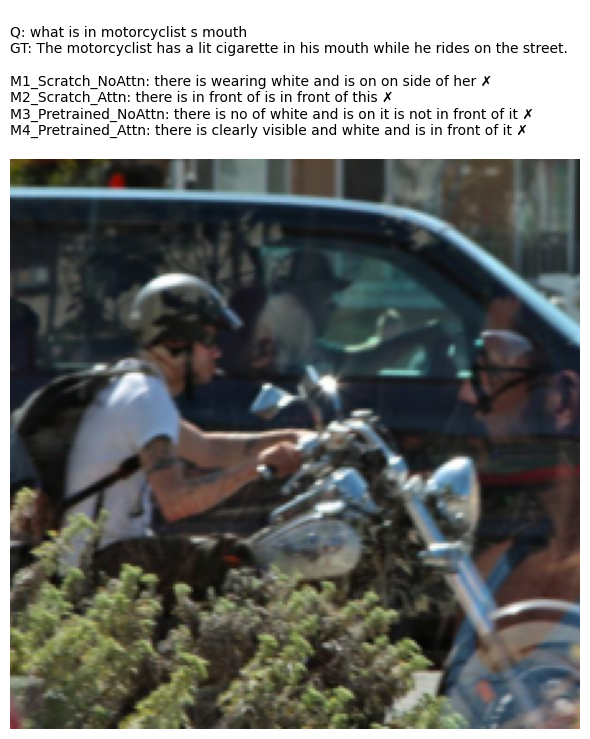

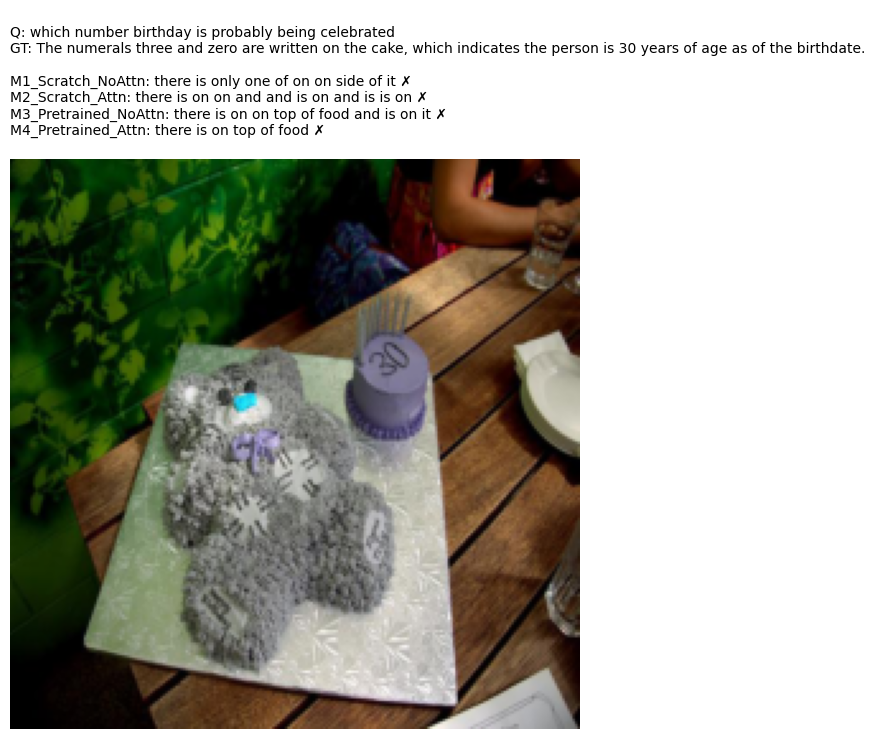

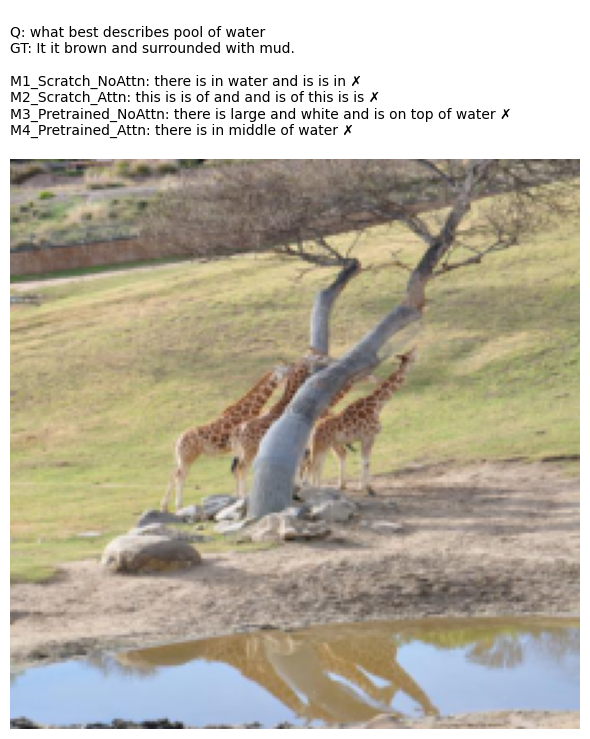

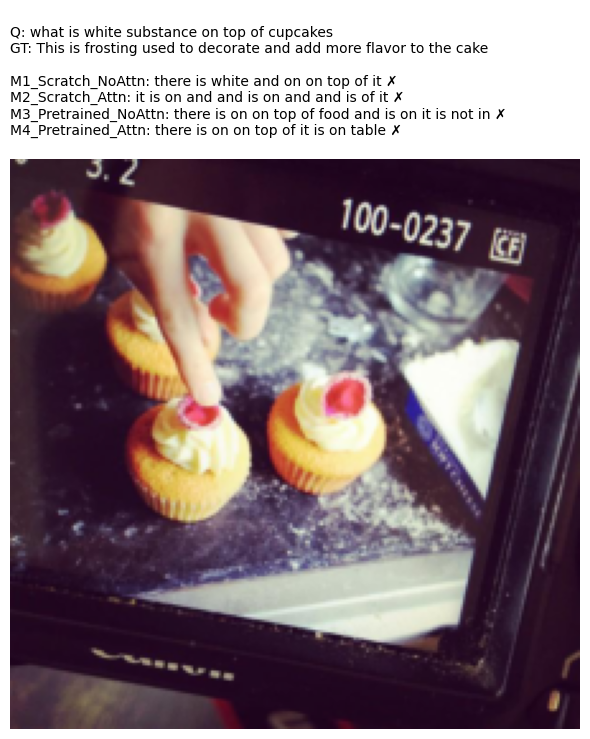

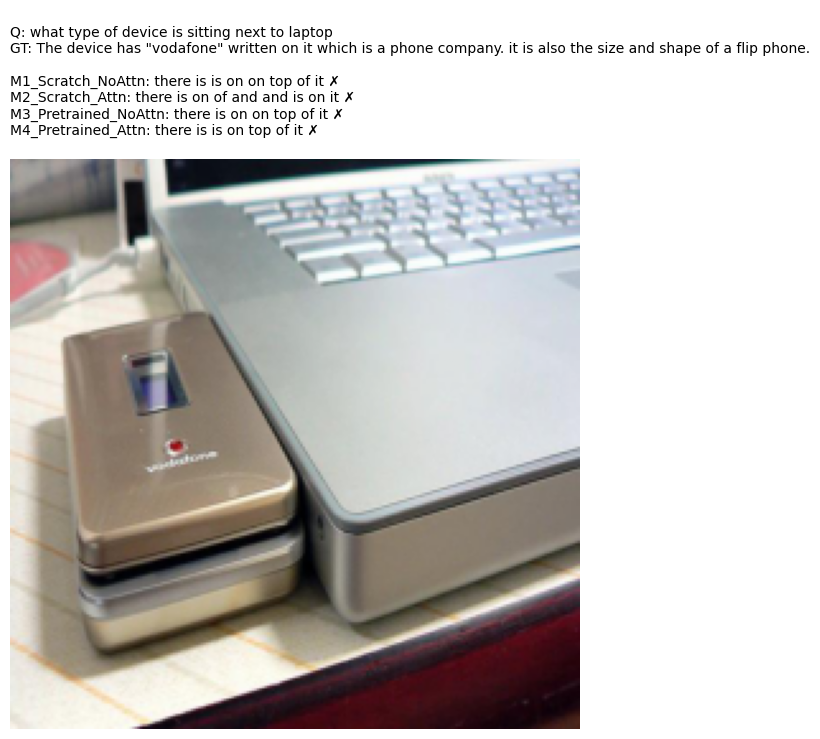

In [ ]:
def show_examples(models_dict, loader, n=5):
    """Visualize predictions from all 4 models on test samples."""
    batch = next(iter(loader))
    imgs, qs, ql, ans, al, ans_txt = batch
    imgs_d, qs_d, ql_d = imgs.to(device), qs.to(device), ql.to(device)

    inv_norm = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225])

    for idx in range(min(n, len(ans_txt))):
        q_text = decode_sequence(qs[idx].tolist(), question_vocab)
        gt = ans_txt[idx]

        plt.figure(figsize=(6, 8))
        img_show = inv_norm(imgs[idx]).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img_show)
        plt.axis("off")

        text_block = f"\nQ: {q_text}\nGT: {gt}\n\n"
        for mname, m in models_dict.items():
            m.eval()
            with torch.no_grad():
                gen = m.generate(imgs_d[idx:idx+1], qs_d[idx:idx+1], ql_d[idx:idx+1])
            pred = decode_sequence(gen[0].cpu().tolist(), answer_vocab)
            ref_str = gt if isinstance(gt, str) else majority_answer(gt)
            tag = "✓" if normalize_answer(pred) == normalize_answer(ref_str) else "✗"
            text_block += f"{mname}: {pred} {tag}\n"

        plt.title(text_block, fontsize=10, loc="left")
        plt.tight_layout()
        plt.show()

show_examples(models_dict, test_loader, n=5)

## 7. Analysis

### Why Pretrained CNN + Attention performs best

| Factor | Scratch CNN | Pretrained CNN | Pretrained + Attention |
|--------|-------------|----------------|------------------------|
| **Image features** | Random init, must learn from scratch | Strong ImageNet features | ImageNet + focus on relevant regions |
| **Convergence** | Slowest | Faster via transfer learning | Fastest |
| **Question grounding** | No explicit alignment | Better image context | Attention aligns decoder to key question tokens |
| **Answer quality** | Generic, short | More accurate | Most detailed and accurate |

### Improvements and impact

| # | Improvement | Impact | Description |
|---|-------------|--------|-------------|
| 1 | **3× Data Expansion** | High | All 3 rationales/question → ~43.5K samples |
| 2 | **LSTM 2L + Dropout 0.3** | High | Deeper model + regularization |
| 3 | **GloVe 300d** | High | Pre-trained semantic embeddings |
| 4 | **Attention Padding Mask** | Medium | Prevents attention leak to \<PAD\> tokens |
| 5 | **Label Smoothing (0.1)** | Medium | Avoids overconfident predictions |
| 6 | **Beam Search + Length Penalty** | Medium | Wu et al. (2016) normalization |
| 7 | **Early Stopping (patience=5)** | Medium | Prevents overfitting |
| 8 | **METEOR metric** | Low | Synonym + stemming aware evaluation |
| 9 | **YAML Config System** | Medium | Reproducible experiments |
| 10 | **Modular Code** | High | Clean separation of concerns |

### Evaluation metrics (8 metrics)

| Metric | Description | Best for |
|--------|-------------|----------|
| **VQA Accuracy** | min(#annotators\_agree / 3, 1.0) | Short answers |
| **Exact Match** | pred == ref after normalization | Short answers |
| **F1** | Token-level harmonic mean of P/R | Medium answers |
| **METEOR** | Synonym + stemming aware overlap | Semantic similarity |
| **BLEU-1** | Unigram precision + brevity penalty | Vocabulary coverage |
| **BLEU-2** | Avg 1,2-gram precision | Phrase quality |
| **BLEU-3** | Avg 1,2,3-gram precision | Sentence structure |
| **BLEU-4** | Avg 1,2,3,4-gram precision | Long answer quality |

---
### 7.1 Question-Type Breakdown

In [ ]:
# ═══════════════  QUESTION-TYPE BREAKDOWN (Best Model)  ═══════════════
best_data = all_eval_data[best_name]

# Classify all test questions by type
print(f"Question-Type Analysis for: {best_name}")
print("=" * 70)

qtype_results = evaluate_by_question_type(
    best_data["preds"], best_data["refs"], best_data["questions"]
)

print(f"\n{'Type':>12s}  {'EM':>8s}  {'F1':>8s}  {'METEOR':>8s}  {'Count':>6s}")
print("-" * 55)
for qtype, stats in qtype_results.items():
    print(f"{qtype:>12s}  {stats['em']:>8.3f}  {stats['f1']:>8.3f}  "
          f"{stats['meteor']:>8.3f}  {int(stats['total']):>6d}")

# Plot detailed question-type chart
plot_question_type_analysis(qtype_results, save_path="fig9_question_type_analysis.png")

### 7.2 Confusion Matrix & Failure Analysis

We compute a **confusion matrix** comparing model predictions (correct vs. incorrect) across question types, and analyze the worst failure cases to understand common error patterns.

In [ ]:
# ═══════════════  CONFUSION MATRIX & FAILURE ANALYSIS  ═══════════════

# --- Confusion matrix (correct vs incorrect by question type) ---
plot_confusion_matrix(
    best_data["preds"], best_data["refs"], best_data["questions"],
    model_name=best_name, save_path="fig10_confusion_matrix.png"
)

# --- Failure cases ---
failures = get_failure_cases(
    best_data["preds"], best_data["refs"], best_data["questions"],
    top_k=15
)

print(f"\nTop-15 Failure Cases for {best_name}")
print("=" * 90)
print(f"{'#':>3s}  {'Type':>10s}  {'Question':40s}  {'Predicted':15s}  {'Reference':15s}")
print("-" * 90)
for i, f in enumerate(failures, 1):
    q = f["question"][:38] + ".." if len(f["question"]) > 40 else f["question"]
    p = f["prediction"][:13] + ".." if len(f["prediction"]) > 15 else f["prediction"]
    r = f["reference"][:13] + ".." if len(f["reference"]) > 15 else f["reference"]
    print(f"{i:>3d}  {f['question_type']:>10s}  {q:40s}  {p:15s}  {r:15s}")

Visualizing attention for: M4_Pretrained_Attn


RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

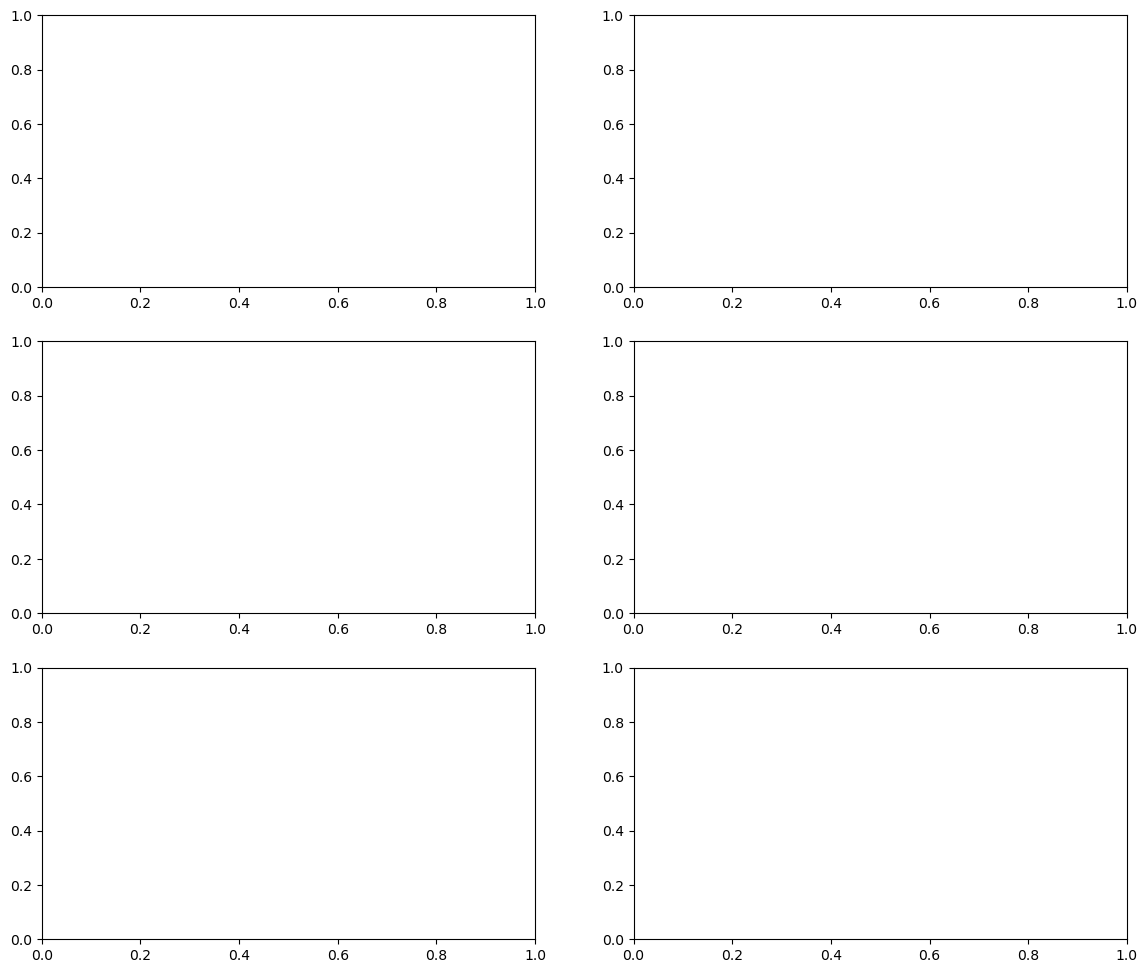

In [ ]:
# ═══════════════  ATTENTION MAP VISUALIZATION  ═══════════════
# Uses modular functions from src/utils/visualization.py
# visualize_attention()        → standard heatmap (answer × question tokens)
# visualize_attention_overlay() → 3-panel: image + bar chart + word overlay

attn_model_name = "M4_Pretrained_Attn" if "M4_Pretrained_Attn" in models_dict else "M2_Scratch_Attn"
print(f"Visualizing attention for: {attn_model_name}")

# 1. Standard attention heatmap
visualize_attention(
    models_dict[attn_model_name], test_loader,
    answer_vocab, question_vocab, device,
    n=3, save_path="fig6_attention_heatmap.png"
)

# 2. Attention overlay (image + question token importance + word cloud)
visualize_attention_overlay(
    models_dict[attn_model_name], test_loader,
    answer_vocab, question_vocab, device,
    n=3, save_path="fig7_attention_overlay.png"
)

## 8. Inference Pipeline

Standalone `VQAInferencePipeline` (see `scripts/inference.py`) supports:
- **Single prediction** with greedy or beam search decoding
- **Batch prediction** from JSON file
- **ONNX export** for deployment

CLI usage:
```bash
python scripts/inference.py --image photo.jpg --question "What color is the car?"
python scripts/inference.py --batch questions.json --output results.json
python scripts/inference.py --export-onnx model.onnx
```

In [ ]:
# ═══════════════  INFERENCE PIPELINE DEMO  ═══════════════
# Full pipeline lives in scripts/inference.py — VQAInferencePipeline class.
# Here we demonstrate it inline for the notebook.

from scripts.inference import VQAInferencePipeline

pipe = VQAInferencePipeline(
    checkpoint_path=os.path.join(cfg.ckpt_dir, f"best_{best_name}.pth"),
    vocab_path="data/processed/vocab_aokvqa.pth",
    device_str=str(device),
)

# Demo: predict on a test example
demo_batch = next(iter(test_loader))
inv_norm = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225])
demo_img = transforms.ToPILImage()(inv_norm(demo_batch[0][0]).clamp(0, 1))
demo_q   = decode_sequence(demo_batch[1][0].tolist(), question_vocab)

answer = pipe.predict(demo_img, demo_q)
print(f"Q : {demo_q}")
print(f"Predicted   : {answer}")
print(f"Ground truth: {demo_batch[5][0]}")

# Show ONNX export capability
print("\nTo export to ONNX, run:")
print(f"  python scripts/inference.py --export-onnx model.onnx \\")
print(f"    --checkpoint {cfg.ckpt_dir}/best_{best_name}.pth")